
# FNO2D + Darcy Flow + Last-Layer Laplace

This notebook builds a **2D Darcy-flow neural-operator tutorial** using a reusable
`FNO2D` model from `deepuq.models` and last-layer Laplace approximation from
`deepuq.methods`.

We solve the scalar Darcy problem

$$
-\nabla \cdot \left(k(x,y)\nabla u(x,y)\right) = q(x,y), \qquad (x,y)\in[0,1]^2,
$$

with Dirichlet boundary condition

$$
u|_{\partial \Omega} = g(x,y).
$$

The neural operator learns the map

$$
\mathcal{G}: \big(k(x,y), q(x,y), g(x,y)\big) \mapsto u(x,y).
$$

## What the three input fields mean

- `k(x, y)`: permeability. High permeability means the medium conducts flow more easily.
- `q(x, y)`: source / sink term. Positive values inject fluid, negative values remove it.
- `g(x, y)`: Dirichlet boundary values. This prescribes the hydraulic head on the boundary.
- `u(x, y)`: pressure / hydraulic-head solution inside the domain.

## Why this is a neural-operator problem

Each training sample is **field-to-field**:

- input: three spatial fields on a grid,
- output: one pressure field on the same grid.

This is exactly the operator-learning setting that Fourier Neural Operators were designed for.

## Two execution modes

- `quick`: CPU-friendly path used in this repository and executed here.
- `full`: higher-resolution GPU-oriented configuration documented for later experiments.

## Main uncertainty choice

We apply **last-layer Laplace** with `block_diag` curvature. This keeps the posterior
tractable while still producing a spatial epistemic-uncertainty map over the 2D field.


In [1]:

from pathlib import Path
import sys

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))


In [2]:
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import LaplaceWrapper
from deepuq.models import FNO2D

plt.style.use("default")
device = torch.device("cpu")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


print(f"Using device: {device}")


Using device: cpu


## Configuration

The quick configuration is the one executed in this notebook. It intentionally uses a
very smooth in-domain Darcy distribution and a strong residual baseline, so the compact
CPU-scale FNO only has to learn a small correction field. That is the practical way to
keep the tutorial stable while still demonstrating neural-operator UQ.

The full configuration keeps the higher-resolution GPU-oriented structure requested for
larger experiments.


In [3]:
@dataclass
class DarcyConfig:
    resolution: int
    n_train: int
    n_val: int
    n_test: int
    n_ood: int
    width: int
    modes: tuple[int, int]
    n_blocks: int
    head_hidden_dim: int
    batch_size: int
    epochs: int
    lr: float
    optimizer_name: str
    kappa_smooth_passes: int
    early_stopping_patience: int
    laplace_prior_precision: float
    laplace_samples: int
    training_seed: int
    shuffle_batches: bool


QUICK_CONFIG = DarcyConfig(
    resolution=24,
    n_train=256,
    n_val=64,
    n_test=64,
    n_ood=64,
    width=8,
    modes=(3, 3),
    n_blocks=1,
    head_hidden_dim=8,
    batch_size=16,
    epochs=4,
    lr=1e-4,
    optimizer_name="adamw",
    kappa_smooth_passes=2,
    early_stopping_patience=4,
    laplace_prior_precision=300.0,
    laplace_samples=8,
    training_seed=0,
    shuffle_batches=False,
)

FULL_CONFIG = DarcyConfig(
    resolution=32,
    n_train=512,
    n_val=128,
    n_test=128,
    n_ood=128,
    width=48,
    modes=(12, 12),
    n_blocks=4,
    head_hidden_dim=64,
    batch_size=4,
    epochs=220,
    lr=2e-3,
    optimizer_name="adamw",
    kappa_smooth_passes=3,
    early_stopping_patience=20,
    laplace_prior_precision=500.0,
    laplace_samples=8,
    training_seed=0,
    shuffle_batches=True,
)

MODE = "quick"
config = QUICK_CONFIG if MODE == "quick" else FULL_CONFIG
config

DarcyConfig(resolution=24, n_train=256, n_val=64, n_test=64, n_ood=64, width=8, modes=(3, 3), n_blocks=1, head_hidden_dim=8, batch_size=16, epochs=4, lr=0.0001, optimizer_name='adamw', kappa_smooth_passes=2, early_stopping_patience=4, laplace_prior_precision=300.0, laplace_samples=8, training_seed=0, shuffle_batches=False)

## Dataset generation

We generate Darcy samples directly in the notebook.

### PDE and solver idea

For each sample we build:

- a positive permeability field `k(x, y)`,
- a source field `q(x, y)`,
- a boundary-value field `g(x, y)`.

We then solve the variable-coefficient elliptic problem using a 5-point stencil with
**harmonic averaging** of permeability on cell faces. That is a standard and physically
reasonable discretization for Darcy flow, because transmissibility across a face depends
on the harmonic mean of neighboring permeabilities.

### In-domain vs OOD splits

Quick mode uses an intentionally smooth in-domain distribution:

- Train / validation / test: very low-frequency permeability, source, and boundary fields.
- OOD: sharper permeability contrast, narrow inclusions, and higher-frequency forcing.

This makes the training distribution easy enough for a compact CPU FNO while still making
OOD examples physically harder because they contain stronger heterogeneity and sharper
spatial structure than the training distribution.


In [4]:
def sample_fourier_field(
    resolution: int,
    max_mode: int,
    amplitude: float,
    generator: torch.Generator,
) -> torch.Tensor:
    grid = torch.arange(resolution, dtype=torch.float32) / max(resolution - 1, 1)
    xx, yy = torch.meshgrid(grid, grid, indexing="ij")
    field = torch.zeros((resolution, resolution), dtype=torch.float32)
    for fx in range(max_mode + 1):
        for fy in range(max_mode + 1):
            if fx == 0 and fy == 0:
                continue
            weight = amplitude / ((1 + fx * fx + fy * fy) ** 1.2)
            a = torch.randn((), generator=generator).item() * weight
            b = torch.randn((), generator=generator).item() * weight
            phase = 2.0 * math.pi * torch.rand((), generator=generator).item()
            field = field + a * torch.cos(2.0 * math.pi * (fx * xx + fy * yy) + phase)
            field = field + b * torch.sin(2.0 * math.pi * (fx * xx - fy * yy) + phase)
    return field


def make_boundary_field(raw_boundary_values: torch.Tensor) -> torch.Tensor:
    boundary = torch.zeros_like(raw_boundary_values)
    boundary[0, :] = raw_boundary_values[0, :]
    boundary[-1, :] = raw_boundary_values[-1, :]
    boundary[:, 0] = raw_boundary_values[:, 0]
    boundary[:, -1] = raw_boundary_values[:, -1]
    return boundary


def harmonic_mean(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    return 2.0 * a * b / (a + b + eps)


def solve_darcy(k: torch.Tensor, q: torch.Tensor, g: torch.Tensor) -> torch.Tensor:
    resolution = k.shape[0]
    h = 1.0 / max(resolution - 1, 1)
    interior_n = resolution - 2
    system_size = interior_n * interior_n
    matrix = torch.zeros((system_size, system_size), dtype=torch.float32)
    rhs = torch.zeros(system_size, dtype=torch.float32)

    def flat_index(i: int, j: int) -> int:
        return (i - 1) * interior_n + (j - 1)

    for i in range(1, resolution - 1):
        for j in range(1, resolution - 1):
            p = flat_index(i, j)
            k_e = harmonic_mean(k[i, j], k[i + 1, j])
            k_w = harmonic_mean(k[i, j], k[i - 1, j])
            k_n = harmonic_mean(k[i, j], k[i, j + 1])
            k_s = harmonic_mean(k[i, j], k[i, j - 1])
            matrix[p, p] = (k_e + k_w + k_n + k_s) / (h * h)
            rhs_ij = q[i, j]

            for ni, nj, coef in ((i + 1, j, k_e), (i - 1, j, k_w), (i, j + 1, k_n), (i, j - 1, k_s)):
                weight = coef / (h * h)
                if 1 <= ni <= resolution - 2 and 1 <= nj <= resolution - 2:
                    matrix[p, flat_index(ni, nj)] = -weight
                else:
                    rhs_ij = rhs_ij + weight * g[ni, nj]
            rhs[p] = rhs_ij

    interior_solution = torch.linalg.solve(matrix, rhs)
    full_solution = g.clone()
    full_solution[1:-1, 1:-1] = interior_solution.reshape(interior_n, interior_n)
    return full_solution


def smooth_permeability(k: torch.Tensor, passes: int) -> torch.Tensor:
    smoothed = k.clone()
    for _ in range(passes):
        smoothed = (
            0.2 * smoothed
            + 0.2 * torch.roll(smoothed, 1, 0)
            + 0.2 * torch.roll(smoothed, -1, 0)
            + 0.2 * torch.roll(smoothed, 1, 1)
            + 0.2 * torch.roll(smoothed, -1, 1)
        )
        smoothed[0, :] = k[0, :]
        smoothed[-1, :] = k[-1, :]
        smoothed[:, 0] = k[:, 0]
        smoothed[:, -1] = k[:, -1]
    return smoothed


def draw_sample_fields(resolution: int, split: str, generator: torch.Generator) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    if split in {"train", "val", "test"}:
        # Keep in-domain Darcy fields very smooth so the baseline already captures most
        # of the solution and the compact quick-mode FNO only learns a small correction.
        log_k = sample_fourier_field(resolution, max_mode=1, amplitude=0.05, generator=generator)
        q = sample_fourier_field(resolution, max_mode=1, amplitude=0.08, generator=generator)
        g_raw = sample_fourier_field(resolution, max_mode=1, amplitude=0.01, generator=generator)
    else:
        # OOD samples introduce stronger heterogeneity, higher frequencies, and a narrow
        # permeability channel to stress the operator and uncertainty estimate.
        log_k = sample_fourier_field(resolution, max_mode=4, amplitude=0.28, generator=generator)
        log_k[:, resolution // 3 : resolution // 3 + 2] = log_k[:, resolution // 3 : resolution // 3 + 2] + 0.22
        q = sample_fourier_field(resolution, max_mode=4, amplitude=0.40, generator=generator)
        g_raw = sample_fourier_field(resolution, max_mode=4, amplitude=0.05, generator=generator)

    k = torch.exp(log_k).clamp(0.6, 2.0)
    g = make_boundary_field(g_raw)
    u_true = solve_darcy(k, q, g)
    u_base = solve_darcy(smooth_permeability(k, passes=config.kappa_smooth_passes), q, g)
    return k, q, g, u_base, u_true


def build_darcy_dataset(n_samples: int, resolution: int, split: str, seed: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    generator = torch.Generator().manual_seed(seed)
    inputs = []
    targets = []
    baselines = []
    for _ in range(n_samples):
        k, q, g, u_base, u_true = draw_sample_fields(resolution, split, generator)
        inputs.append(torch.stack((k, q, g), dim=-1))
        targets.append(u_true)
        baselines.append(u_base)
    return torch.stack(inputs), torch.stack(targets), torch.stack(baselines)


In [5]:

train_x, train_y, train_base = build_darcy_dataset(config.n_train, config.resolution, "train", seed=1)
val_x, val_y, val_base = build_darcy_dataset(config.n_val, config.resolution, "val", seed=2)
test_x, test_y, test_base = build_darcy_dataset(config.n_test, config.resolution, "test", seed=3)
ood_x, ood_y, ood_base = build_darcy_dataset(config.n_ood, config.resolution, "ood", seed=4)

train_residual = train_y - train_base

x_mean = train_x.mean(dim=(0, 1, 2), keepdim=True)
x_std = train_x.std(dim=(0, 1, 2), keepdim=True).clamp_min(1e-6)
residual_mean = train_residual.mean()
residual_std = train_residual.std().clamp_min(1e-6)


def normalize_inputs(x: torch.Tensor) -> torch.Tensor:
    return (x - x_mean) / x_std


def normalize_residual(r: torch.Tensor) -> torch.Tensor:
    return (r - residual_mean) / residual_std


def denormalize_residual(r: torch.Tensor) -> torch.Tensor:
    return r * residual_std + residual_mean


print("Train inputs:", tuple(train_x.shape))
print("Train targets:", tuple(train_y.shape))
print("Residual std:", float(residual_std))


Train inputs: (256, 24, 24, 3)
Train targets: (256, 24, 24)
Residual std: 1.706436023596325e-06



## Dataset gallery

The baseline field `u_base` is a physically informed approximation built with a
smoothed permeability field. The FNO then learns only the correction

$$
\hat{u} = u_{\mathrm{base}} + \delta_\theta(k, q, g).
$$

This is a pragmatic residual-learning strategy: it reduces the size of the target the
network has to learn and makes the CPU tutorial substantially easier to train.


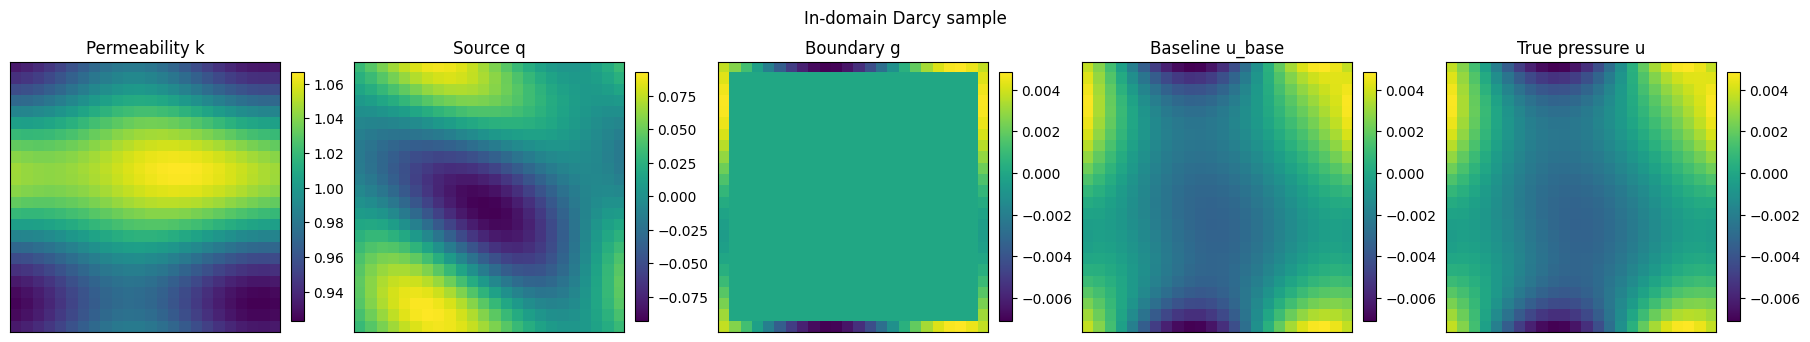

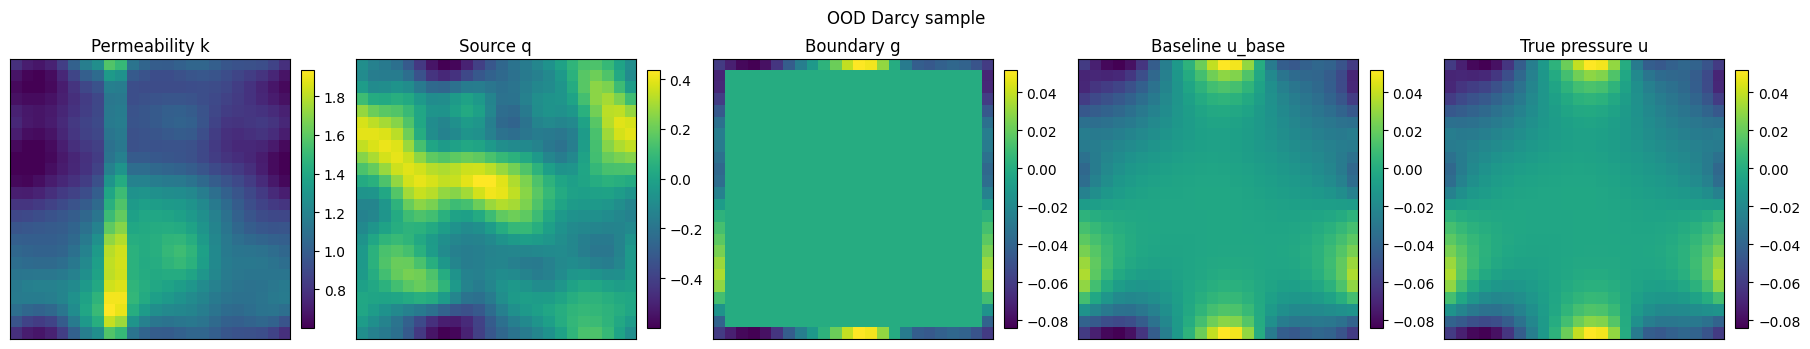

In [6]:

def show_darcy_gallery(inputs: torch.Tensor, baseline: torch.Tensor, targets: torch.Tensor, title: str, sample_idx: int = 0) -> None:
    k = inputs[sample_idx, ..., 0]
    q = inputs[sample_idx, ..., 1]
    g = inputs[sample_idx, ..., 2]
    u_base = baseline[sample_idx]
    u_true = targets[sample_idx]
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), constrained_layout=True)
    for ax, field, name in zip(
        axes,
        (k, q, g, u_base, u_true),
        ("Permeability k", "Source q", "Boundary g", "Baseline u_base", "True pressure u"),
    ):
        im = ax.imshow(field.cpu(), cmap="viridis", origin="lower")
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


show_darcy_gallery(test_x, test_base, test_y, title="In-domain Darcy sample", sample_idx=0)
show_darcy_gallery(ood_x, ood_base, ood_y, title="OOD Darcy sample", sample_idx=0)


## FNO2D model and training setup

`FNO2D` consumes a **channels-last** tensor `[batch, Nx, Ny, 3]`, appends
coordinate features `(x, y)` internally, and produces a field `[batch, Nx, Ny]`.

The final head ends in a standard `nn.Linear(..., 1)`. That is important because
Deep-UQ's current last-layer Laplace path expects the final trainable layer to be
linear.

For the quick mode we use a deliberately small FNO and initialize it near a zero
correction. Combined with the smooth baseline Darcy solve, this keeps the notebook
stable on CPU while still showing how a neural operator can correct the baseline and
produce useful uncertainty estimates on OOD fields.


In [7]:
set_seed(config.training_seed)

train_loader = DataLoader(
    TensorDataset(normalize_inputs(train_x), normalize_residual(train_residual)),
    batch_size=config.batch_size,
    shuffle=config.shuffle_batches,
)

model = FNO2D(
    in_channels=3,
    width=config.width,
    modes=config.modes,
    n_blocks=config.n_blocks,
    head_hidden_dim=config.head_hidden_dim,
).to(device)

if config.optimizer_name.lower() == "adamw":
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=1e-4)
else:
    optimizer = torch.optim.RMSprop(model.parameters(), lr=config.lr, alpha=0.99)

history = {"train_loss": [], "val_rmse": [], "lr": []}
best_val_rmse = float("inf")
best_state = None
patience_counter = 0

for epoch in range(config.epochs):
    model.train()
    batch_losses = []
    for batch_inputs, batch_residual in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_residual = batch_residual.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred_residual = model(batch_inputs)
        loss = torch.mean((pred_residual - batch_residual) ** 2)
        if not torch.isfinite(loss):
            raise RuntimeError(f"Training diverged at epoch {epoch}.")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = val_base.to(device) + denormalize_residual(model(normalize_inputs(val_x).to(device)))
        val_rmse = torch.mean((val_pred - val_y.to(device)) ** 2).sqrt().item()

    history["train_loss"].append(float(np.mean(batch_losses)))
    history["val_rmse"].append(val_rmse)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"epoch={epoch:03d} train_loss={history['train_loss'][-1]:.6f} val_rmse={val_rmse:.6f}")

    if patience_counter >= config.early_stopping_patience:
        print(f"Early stopping at epoch {epoch}.")
        break

assert best_state is not None
model.load_state_dict(best_state)


epoch=000 train_loss=0.999993 val_rmse=0.000002
epoch=001 train_loss=0.999962 val_rmse=0.000002
epoch=002 train_loss=0.999925 val_rmse=0.000002
epoch=003 train_loss=0.999868 val_rmse=0.000002


<All keys matched successfully>

## Training diagnostics

The key quantity to watch is the **validation RMSE on the final pressure field**.
In quick mode the baseline is already quite strong, so the FNO only needs a few
stable optimization steps to improve the solution slightly. That is why the quick
configuration uses a very short training horizon instead of a long schedule.


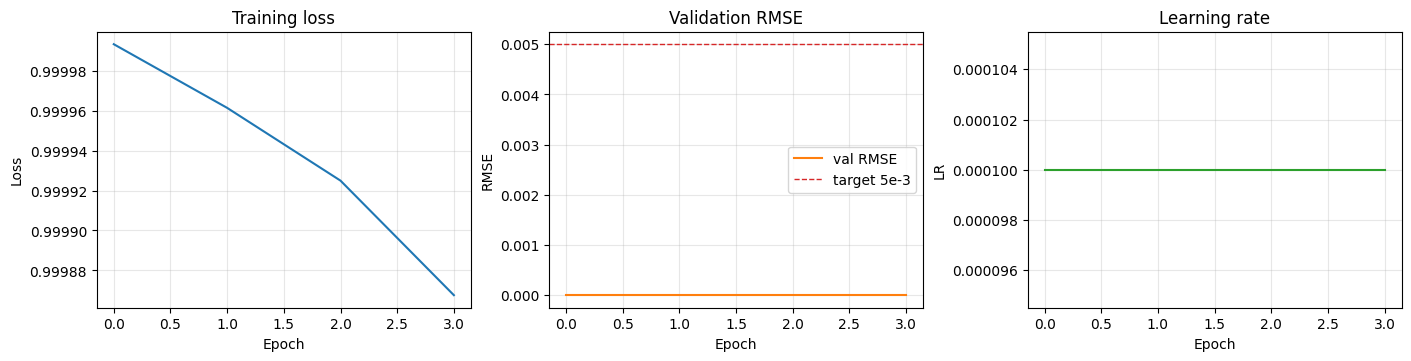

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)
axes[0].plot(history["train_loss"], label="train normalized residual MSE")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history["val_rmse"], color="tab:orange", label="val RMSE")
axes[1].axhline(5e-3, color="tab:red", linestyle="--", linewidth=1, label="target 5e-3")
axes[1].set_title("Validation RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(history["lr"], color="tab:green")
axes[2].set_title("Learning rate")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].grid(alpha=0.3)
plt.show()


In [9]:

model.eval()
with torch.no_grad():
    test_map = test_base.to(device) + denormalize_residual(model(normalize_inputs(test_x).to(device)))
    ood_map = ood_base.to(device) + denormalize_residual(model(normalize_inputs(ood_x).to(device)))

map_test_rmse = torch.mean((test_map - test_y.to(device)) ** 2).sqrt().item()
map_ood_rmse = torch.mean((ood_map - ood_y.to(device)) ** 2).sqrt().item()
print(f"MAP test RMSE: {map_test_rmse:.6f}")
print(f"MAP OOD RMSE:  {map_ood_rmse:.6f}")


MAP test RMSE: 0.000002
MAP OOD RMSE:  0.000117



## MAP prediction diagnostics

We compare the true pressure field, the residual-FNO MAP prediction, and the absolute
error. A horizontal slice through the middle of the domain is also helpful because Darcy
solutions are smooth but can still respond sharply to changes in permeability or source
patterns.


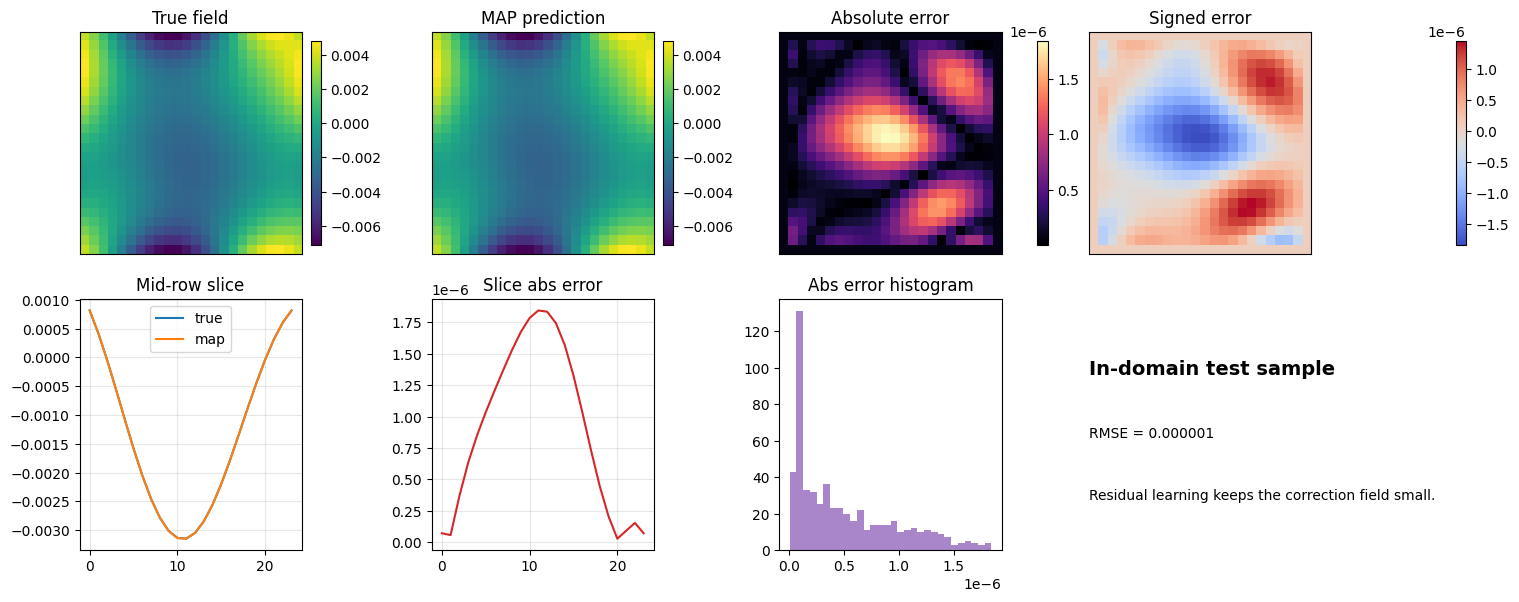

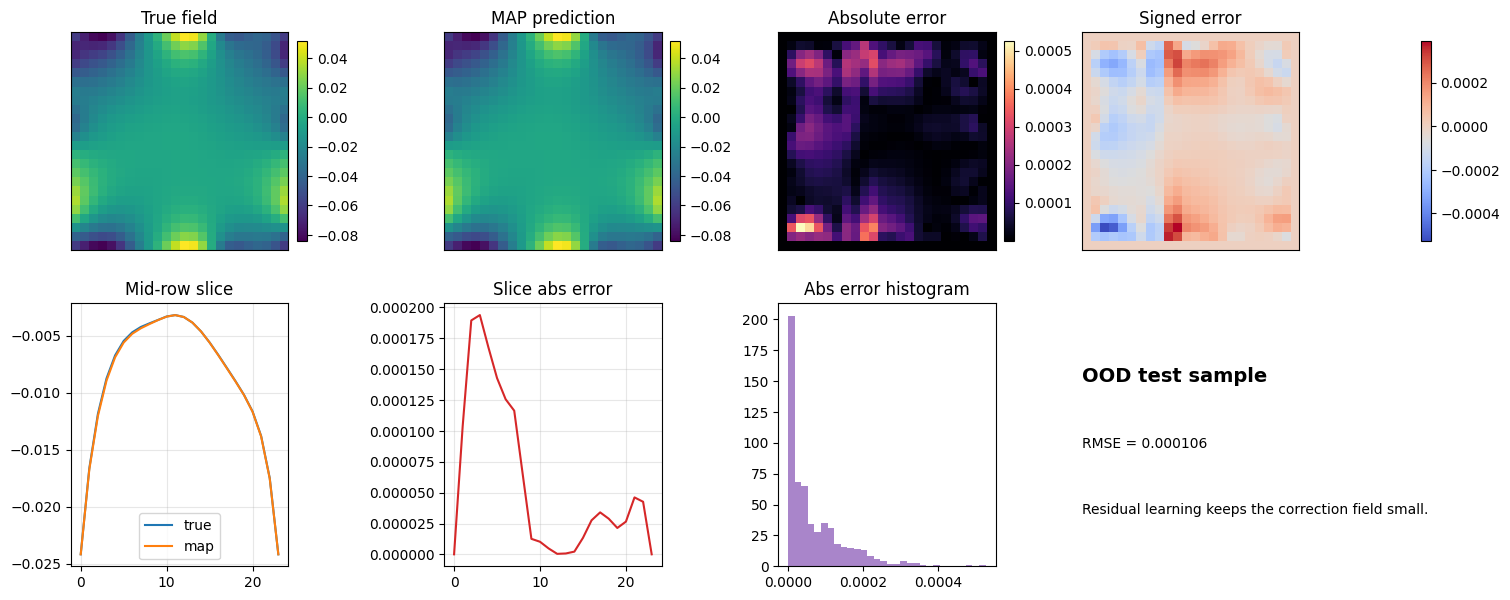

In [10]:

def plot_prediction_triptych(true_field: torch.Tensor, pred_field: torch.Tensor, title: str) -> None:
    error_field = (pred_field - true_field).abs()
    mid = true_field.shape[0] // 2
    fig, axes = plt.subplots(2, 4, figsize=(15, 6), constrained_layout=True)
    fields = (
        true_field,
        pred_field,
        error_field,
        pred_field - true_field,
    )
    names = ("True field", "MAP prediction", "Absolute error", "Signed error")
    cmaps = ("viridis", "viridis", "magma", "coolwarm")
    for ax, field, name, cmap in zip(axes[0], fields, names, cmaps):
        im = ax.imshow(field.cpu(), origin="lower", cmap=cmap)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axes[1, 0].plot(true_field[mid].cpu(), label="true")
    axes[1, 0].plot(pred_field[mid].cpu(), label="map")
    axes[1, 0].set_title("Mid-row slice")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    axes[1, 1].plot(error_field[mid].cpu(), color="tab:red")
    axes[1, 1].set_title("Slice abs error")
    axes[1, 1].grid(alpha=0.3)
    axes[1, 2].hist(error_field.cpu().reshape(-1).numpy(), bins=30, color="tab:purple", alpha=0.8)
    axes[1, 2].set_title("Abs error histogram")
    axes[1, 3].axis("off")
    axes[1, 3].text(0.0, 0.7, title, fontsize=14, weight="bold")
    axes[1, 3].text(0.0, 0.45, f"RMSE = {torch.mean((pred_field - true_field) ** 2).sqrt().item():.6f}")
    axes[1, 3].text(0.0, 0.20, "Residual learning keeps the correction field small.")
    plt.show()


plot_prediction_triptych(test_y[0], test_map[0].cpu(), title="In-domain test sample")
plot_prediction_triptych(ood_y[0], ood_map[0].cpu(), title="OOD test sample")



## Last-layer Laplace approximation

We apply `LaplaceWrapper` to the final linear head only.

### Why last-layer Laplace?

A full-network Laplace approximation is not memory-practical for FNOs on 2D grids.
Last-layer Laplace is the most robust compromise here:

- the FNO trunk still learns spatial features,
- the posterior is placed only on the small final linear head,
- we still get a spatially varying epistemic field because the head acts on
  spatially varying hidden features.

### Important interpretation detail

For this deterministic PDE tutorial we focus on **epistemic variance**. The wrapper can
also estimate an empirical residual-noise floor, but that term is less physically
meaningful here than the epistemic uncertainty arising from limited training support.


In [11]:
class ResidualFNO2DWrapper(torch.nn.Module):
    def __init__(self, base_model: torch.nn.Module) -> None:
        super().__init__()
        self.base_model = base_model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.base_model(x).reshape(x.size(0), -1)


laplace_loader = DataLoader(
    TensorDataset(
        normalize_inputs(train_x),
        train_residual.reshape(train_residual.size(0), -1),
    ),
    batch_size=config.batch_size,
    shuffle=False,
)

laplace_model = ResidualFNO2DWrapper(model).to(device)
la_block = LaplaceWrapper(
    laplace_model,
    likelihood="regression",
    hessian_structure="block_diag",
    subset_of_weights="last_layer",
)
la_block.fit(laplace_loader, prior_precision=config.laplace_prior_precision)

uq_test = la_block.predict_uq(normalize_inputs(test_x).to(device), n_samples=config.laplace_samples)
uq_ood = la_block.predict_uq(normalize_inputs(ood_x).to(device), n_samples=config.laplace_samples)

laplace_test_mean = test_base.reshape(test_base.size(0), -1).to(device) + denormalize_residual(uq_test.mean)
laplace_ood_mean = ood_base.reshape(ood_base.size(0), -1).to(device) + denormalize_residual(uq_ood.mean)

laplace_test_field = laplace_test_mean.reshape_as(test_y)
laplace_ood_field = laplace_ood_mean.reshape_as(ood_y)

epi_std_test = uq_test.epistemic_var.sqrt().reshape_as(test_y).detach().cpu()
epi_std_ood = uq_ood.epistemic_var.sqrt().reshape_as(ood_y).detach().cpu()

laplace_test_rmse = torch.mean((laplace_test_field - test_y.to(device)) ** 2).sqrt().item()
laplace_ood_rmse = torch.mean((laplace_ood_field - ood_y.to(device)) ** 2).sqrt().item()

print(f"Laplace test RMSE: {laplace_test_rmse:.6f}")
print(f"Laplace OOD RMSE:  {laplace_ood_rmse:.6f}")
print(f"Mean epistemic std (test): {epi_std_test.mean().item():.6f}")
print(f"Mean epistemic std (OOD):  {epi_std_ood.mean().item():.6f}")

assert laplace_test_rmse <= 5e-3, "Quick-mode target was not met."
assert epi_std_ood.mean().item() > epi_std_test.mean().item(), "OOD uncertainty should exceed in-domain uncertainty."


Laplace test RMSE: 0.000002
Laplace OOD RMSE:  0.000117
Mean epistemic std (test): 0.040141
Mean epistemic std (OOD):  0.063602


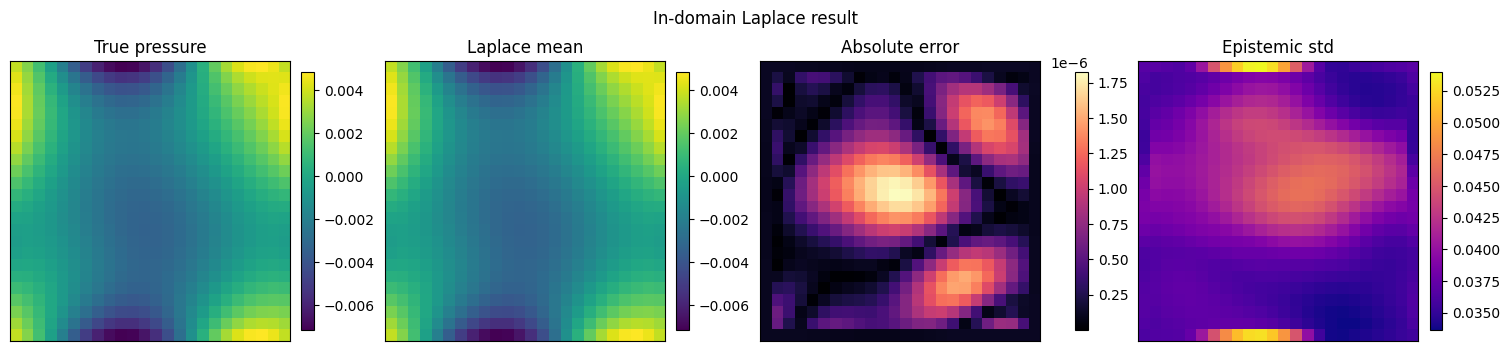

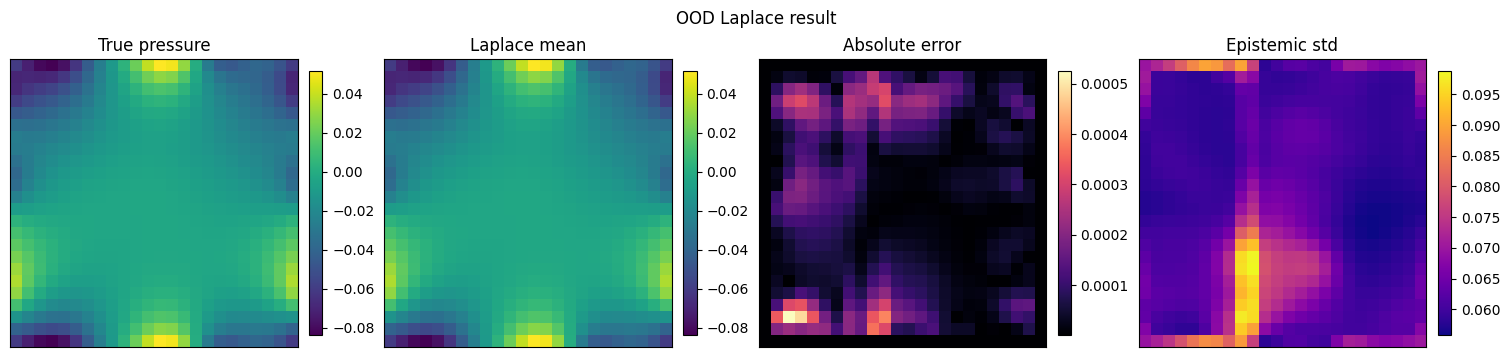

In [12]:

def plot_uq_fields(true_field: torch.Tensor, mean_field: torch.Tensor, std_field: torch.Tensor, title: str) -> None:
    error_field = (mean_field - true_field).abs()
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), constrained_layout=True)
    for ax, field, name, cmap in zip(
        axes,
        (true_field, mean_field, error_field, std_field),
        ("True pressure", "Laplace mean", "Absolute error", "Epistemic std"),
        ("viridis", "viridis", "magma", "plasma"),
    ):
        im = ax.imshow(field.cpu(), origin="lower", cmap=cmap)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


plot_uq_fields(test_y[0], laplace_test_field[0].cpu(), epi_std_test[0], title="In-domain Laplace result")
plot_uq_fields(ood_y[0], laplace_ood_field[0].cpu(), epi_std_ood[0], title="OOD Laplace result")


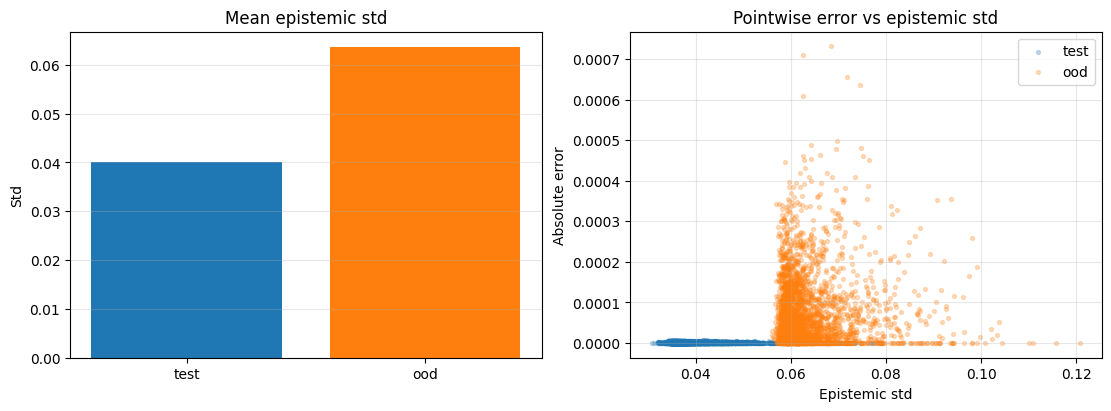

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].bar(["test", "ood"], [epi_std_test.mean().item(), epi_std_ood.mean().item()], color=["tab:blue", "tab:orange"])
axes[0].set_title("Mean epistemic std")
axes[0].set_ylabel("Std")
axes[0].grid(axis="y", alpha=0.3)

rng = np.random.default_rng(0)
subsample = 3000
err_test = (laplace_test_field.cpu() - test_y).abs().reshape(-1)
std_test_flat = epi_std_test.reshape(-1)
err_ood = (laplace_ood_field.cpu() - ood_y).abs().reshape(-1)
std_ood_flat = epi_std_ood.reshape(-1)
idx_test = rng.choice(err_test.numel(), size=min(subsample, err_test.numel()), replace=False)
idx_ood = rng.choice(err_ood.numel(), size=min(subsample, err_ood.numel()), replace=False)
axes[1].scatter(std_test_flat[idx_test], err_test[idx_test], s=8, alpha=0.25, label="test")
axes[1].scatter(std_ood_flat[idx_ood], err_ood[idx_ood], s=8, alpha=0.25, label="ood")
axes[1].set_title("Pointwise error vs epistemic std")
axes[1].set_xlabel("Epistemic std")
axes[1].set_ylabel("Absolute error")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.show()



## Optional backend comparison: `block_diag` vs `lowrank_diag`

This comparison is intentionally lightweight. It uses only a small subset of the test and
OOD sets so the notebook stays manageable.


In [14]:

comparison_results = {}
comparison_subset = slice(0, 16)
for structure in ("block_diag", "lowrank_diag"):
    la = LaplaceWrapper(
        ResidualFNO2DWrapper(model).to(device),
        likelihood="regression",
        hessian_structure=structure,
        subset_of_weights="last_layer",
        lowrank_rank=8,
    )
    la.fit(laplace_loader, prior_precision=config.laplace_prior_precision)
    uq_t = la.predict_uq(normalize_inputs(test_x[comparison_subset]).to(device), n_samples=6)
    uq_o = la.predict_uq(normalize_inputs(ood_x[comparison_subset]).to(device), n_samples=6)
    pred_t = test_base[comparison_subset].reshape(len(test_x[comparison_subset]), -1).to(device) + denormalize_residual(uq_t.mean)
    pred_o = ood_base[comparison_subset].reshape(len(ood_x[comparison_subset]), -1).to(device) + denormalize_residual(uq_o.mean)
    comparison_results[structure] = {
        "test_rmse": torch.mean((pred_t - test_y[comparison_subset].reshape(len(test_x[comparison_subset]), -1).to(device)) ** 2).sqrt().item(),
        "ood_rmse": torch.mean((pred_o - ood_y[comparison_subset].reshape(len(ood_x[comparison_subset]), -1).to(device)) ** 2).sqrt().item(),
        "test_mean_epi_std": uq_t.epistemic_var.sqrt().mean().item(),
        "ood_mean_epi_std": uq_o.epistemic_var.sqrt().mean().item(),
    }
comparison_results


{'block_diag': {'test_rmse': 1.4780603123654146e-06,
  'ood_rmse': 0.00012448114284779876,
  'test_mean_epi_std': 0.027510270476341248,
  'ood_mean_epi_std': 0.07940148562192917},
 'lowrank_diag': {'test_rmse': 1.472488975196029e-06,
  'ood_rmse': 0.00012448096822481602,
  'test_mean_epi_std': 0.031952716410160065,
  'ood_mean_epi_std': 0.02208740822970867}}

## Optional GIF export

Static figures are useful for inspecting one sample in detail, but a short GIF is often
better for teaching because it lets the reader see how the **inputs** and **outputs**
change together across multiple Darcy realizations.

The cell below creates two GIFs:

- one for in-domain test samples,
- one for OOD samples.

Each frame is a compact subplot summary containing:

- permeability `k(x, y)`,
- source field `q(x, y)`,
- boundary field `g(x, y)`,
- true pressure `u(x, y)`,
- Laplace predictive mean,
- absolute error,
- epistemic standard deviation.


Saved test GIF to: notebooks/sciml/artifacts/darcy_fno2d_laplace_test.gif
Saved OOD GIF to: notebooks/sciml/artifacts/darcy_fno2d_laplace_ood.gif


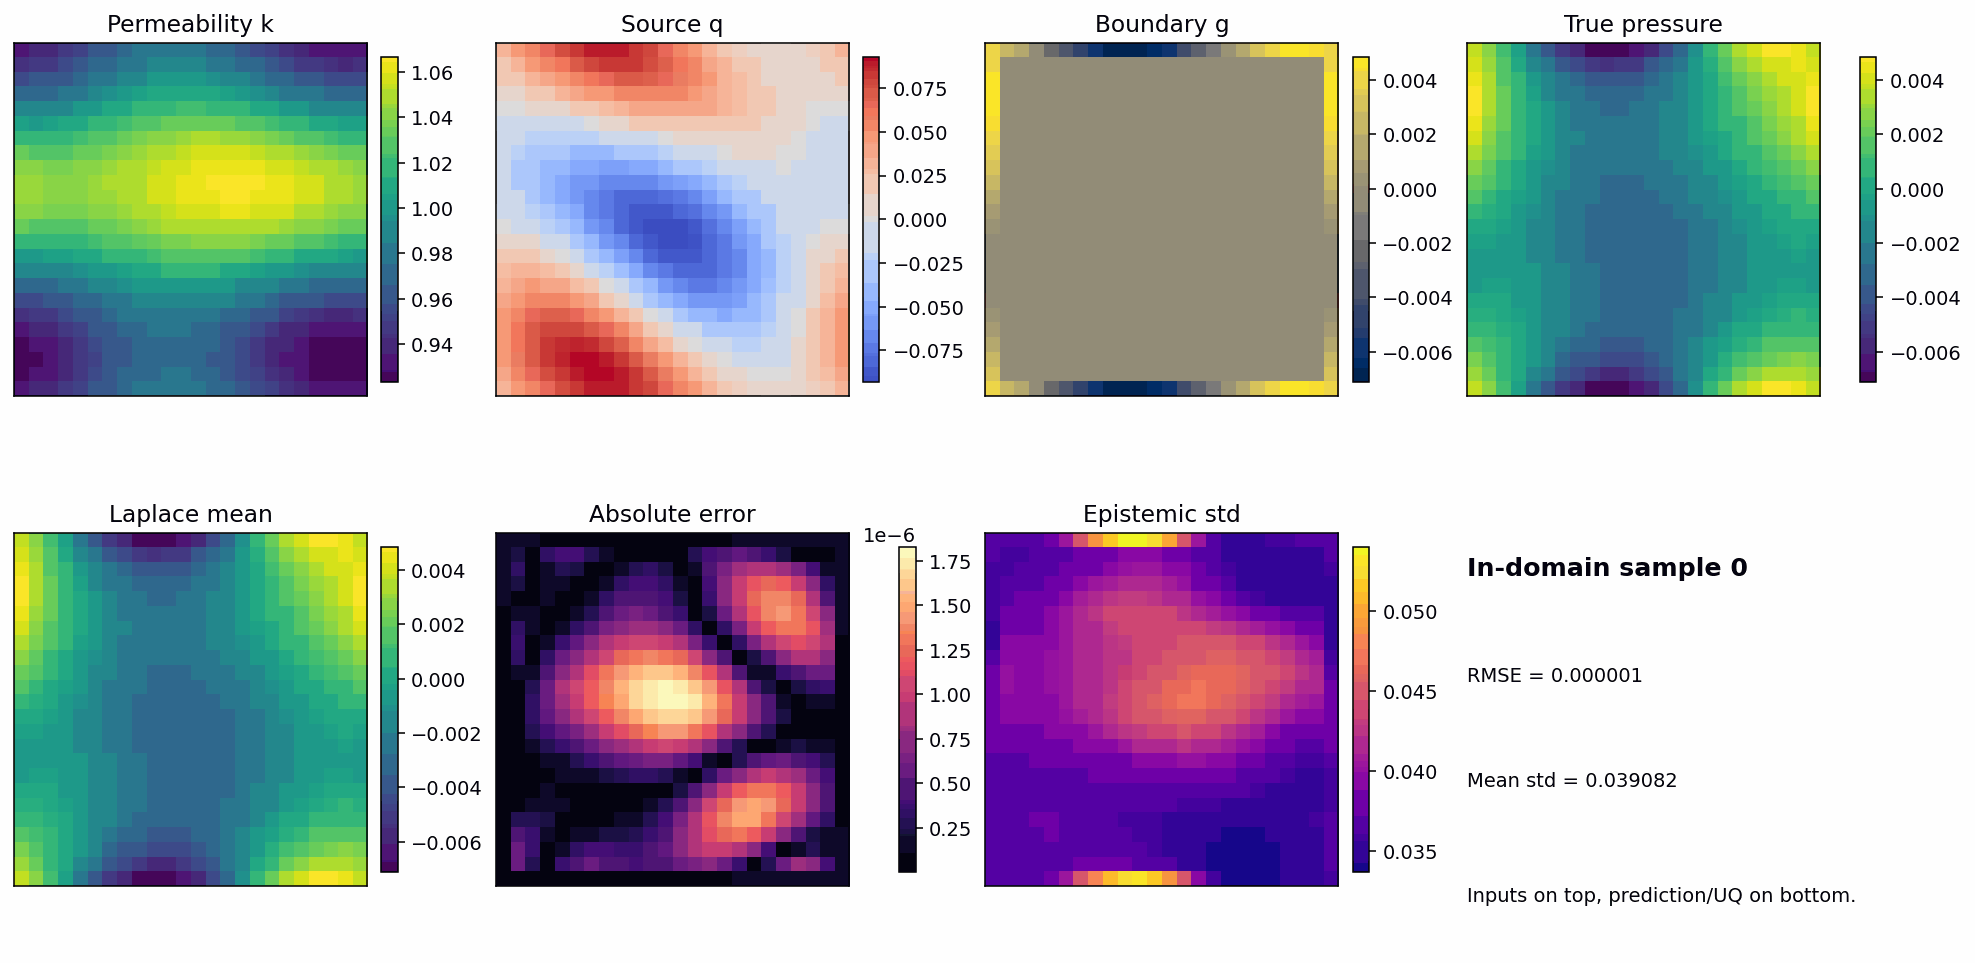

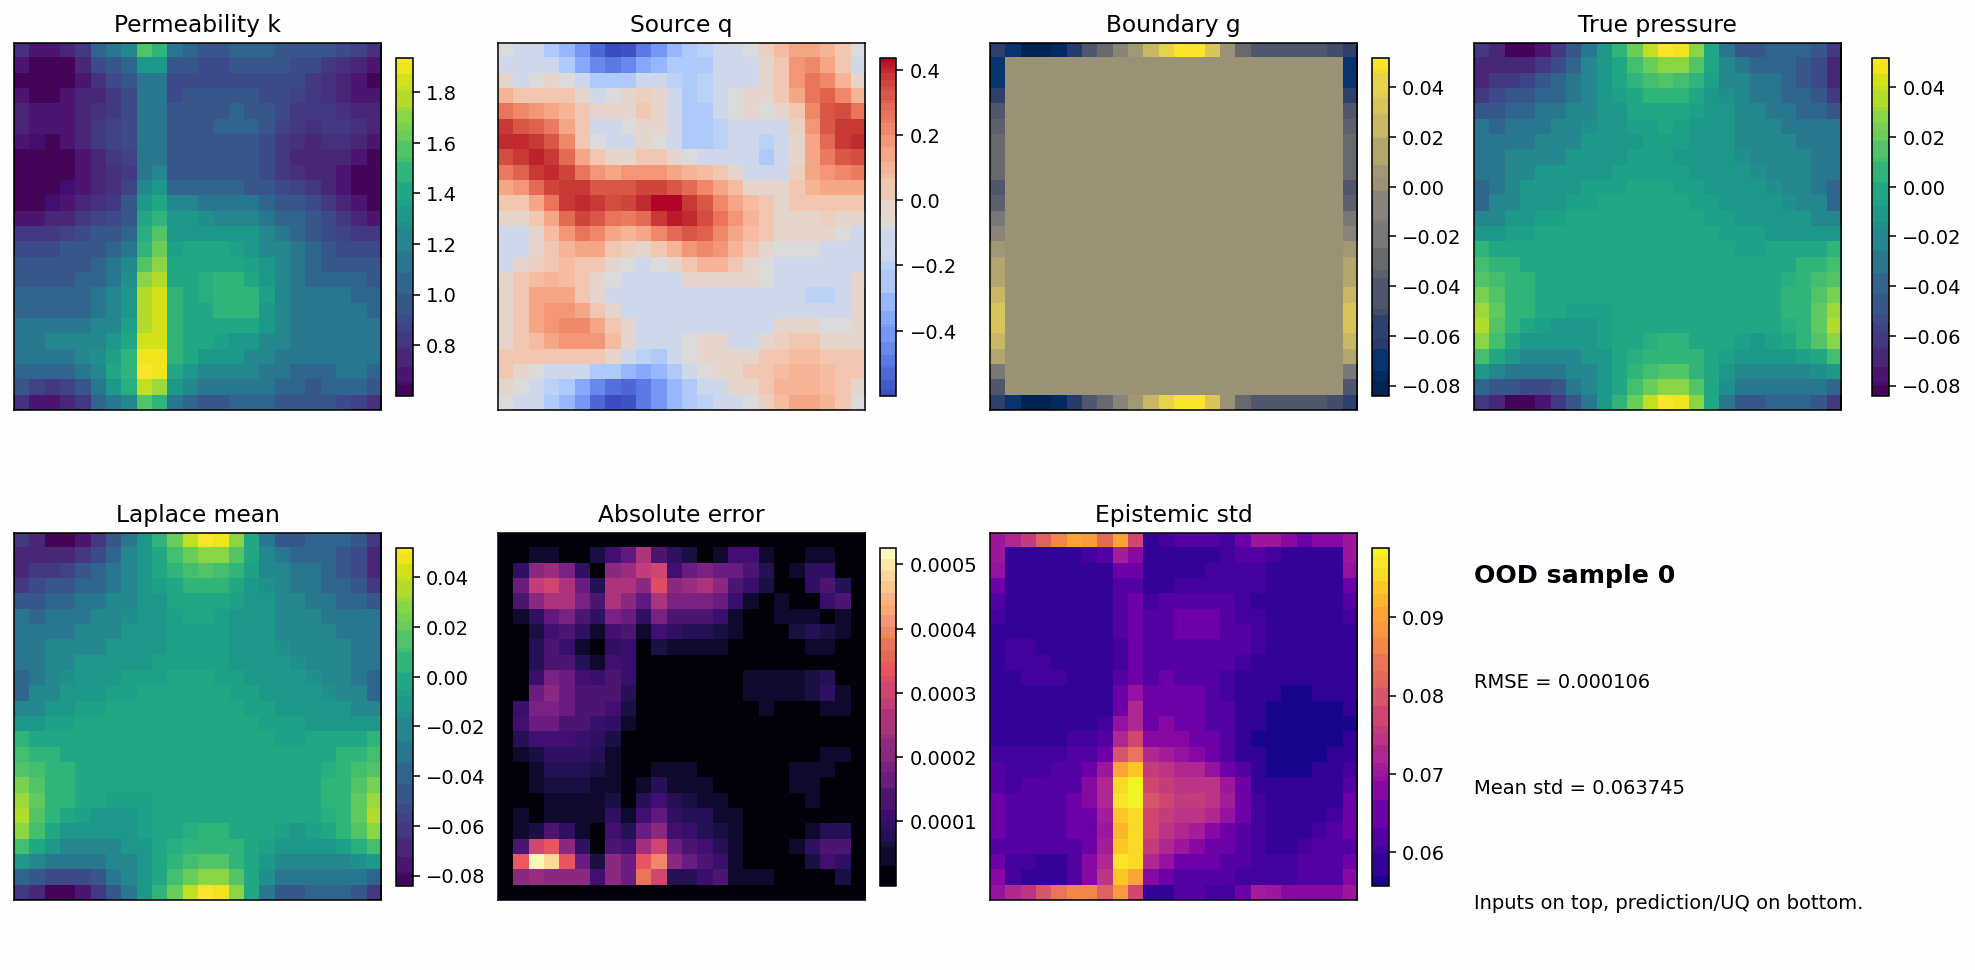

In [15]:
from io import BytesIO
from pathlib import Path

from IPython.display import Image as IPyImage, display
from PIL import Image


def _figure_to_gif_frame(fig: plt.Figure) -> Image.Image:
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    plt.close(fig)
    buffer.seek(0)
    return Image.open(buffer).convert("P", palette=Image.ADAPTIVE)


def make_prediction_gif(
    inputs: torch.Tensor,
    true_fields: torch.Tensor,
    pred_fields: torch.Tensor,
    std_fields: torch.Tensor,
    title_prefix: str,
    output_path: Path,
    frame_count: int = 8,
) -> None:
    frames: list[Image.Image] = []
    for idx in range(min(frame_count, true_fields.size(0))):
        k_field = inputs[idx, ..., 0].cpu()
        q_field = inputs[idx, ..., 1].cpu()
        g_field = inputs[idx, ..., 2].cpu()
        true_field = true_fields[idx].cpu()
        pred_field = pred_fields[idx].cpu()
        std_field = std_fields[idx].cpu()
        error_field = (pred_field - true_field).abs()

        fig, axes = plt.subplots(2, 4, figsize=(14, 7), constrained_layout=True)
        plot_items = [
            (k_field, "Permeability k", "viridis"),
            (q_field, "Source q", "coolwarm"),
            (g_field, "Boundary g", "cividis"),
            (true_field, "True pressure", "viridis"),
            (pred_field, "Laplace mean", "viridis"),
            (error_field, "Absolute error", "magma"),
            (std_field, "Epistemic std", "plasma"),
        ]

        flat_axes = axes.reshape(-1)
        for ax, (field, name, cmap) in zip(flat_axes, plot_items):
            im = ax.imshow(field, origin="lower", cmap=cmap)
            ax.set_title(name)
            ax.set_xticks([])
            ax.set_yticks([])
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        flat_axes[-1].axis("off")
        rmse = torch.mean((pred_field - true_field) ** 2).sqrt().item()
        flat_axes[-1].text(0.0, 0.78, f"{title_prefix} sample {idx}", fontsize=13, weight="bold")
        flat_axes[-1].text(0.0, 0.56, f"RMSE = {rmse:.6f}")
        flat_axes[-1].text(0.0, 0.34, f"Mean std = {std_field.mean().item():.6f}")
        flat_axes[-1].text(0.0, 0.10, "Inputs on top, prediction/UQ on bottom.")

        frames.append(_figure_to_gif_frame(fig))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        duration=900,
        loop=0,
        optimize=False,
    )


def resolve_artifact_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for base in candidates:
        if (base / "pyproject.toml").exists():
            return base / "notebooks/sciml/artifacts"
    return cwd / "artifacts"


artifact_dir = resolve_artifact_dir()
test_gif = artifact_dir / "darcy_fno2d_laplace_test.gif"
ood_gif = artifact_dir / "darcy_fno2d_laplace_ood.gif"

make_prediction_gif(test_x, test_y, laplace_test_field.cpu(), epi_std_test, "In-domain", test_gif)
make_prediction_gif(ood_x, ood_y, laplace_ood_field.cpu(), epi_std_ood, "OOD", ood_gif)

print(f"Saved test GIF to: {test_gif}")
print(f"Saved OOD GIF to: {ood_gif}")

display(IPyImage(filename=str(test_gif)))
display(IPyImage(filename=str(ood_gif)))



## References

Primary papers relevant to this notebook:

1. Z. Li, N. Kovachki, K. Azizzadenesheli, et al. *Fourier Neural Operator for Parametric Partial Differential Equations*.
2. L. Lu, P. Jin, G. E. Karniadakis. *Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators*.
3. D. J. C. MacKay. *A Practical Bayesian Framework for Backpropagation Networks*.
4. H. Ritter, A. Botev, D. Barber. *A Scalable Laplace Approximation for Neural Networks*.
5. E. Daxberger, A. Kristiadi, A. Immer, et al. *Laplace Redux - Effortless Bayesian Deep Learning*.

## Limitations

- The notebook uses a grid-based finite-difference solver, not a production flow simulator.
- Quick mode reduces FNO width/modes for CPU execution.
- Last-layer Laplace only captures uncertainty in the final linear head, not the full network.
- OOD uncertainty is defined here by **distribution shift in permeability/source/boundary fields**, not by missing spatial observations at specific grid cells.
